#### Исследование линейной регрессии
**Датасет** Price of Used Toyota Corolla Cars

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('ToyotaCorolla.csv')

In [3]:
df.shape

(1436, 39)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [5]:
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [6]:
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [7]:
# ищу выбросы по методам статистического анализа
num_cols = df.select_dtypes(include=[np.number]).columns
# исключаем бинарные признаки
continuous_cols = [col for col in num_cols if df[col].nunique() > 2] 
emissions = {}
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_b = Q1 - 3 * IQR
    upper_b = Q3 + 3 * IQR
    outliers = df[(df[col] < lower_b) | (df[col] > upper_b)][col]
    emissions[col] = outliers.tolist()

print("Выбросы по IQR:")
for col, vals in emissions.items():
    if vals:
        print(f"{col}: {len(vals)}")

Выбросы по IQR:
Price: 14
KM: 2
HP: 11
CC: 1
Gears: 46
Quarterly_Tax: 223
Weight: 30
Guarantee_Period: 162


In [8]:
# посмотрю по процентилям
outliers_by_p = {}
for col in continuous_cols:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers = df.loc[mask, col]
    
    outliers_by_p[col] = outliers.tolist()
    
for col, vals in outliers_by_p.items():
    if vals:
        print(f"{col}: {len(vals)} выбросов")

Id: 30 выбросов
Price: 29 выбросов
Age_08_04: 13 выбросов
KM: 30 выбросов
HP: 11 выбросов
CC: 1 выбросов
Doors: 2 выбросов
Gears: 3 выбросов
Quarterly_Tax: 3 выбросов
Weight: 15 выбросов
Guarantee_Period: 12 выбросов


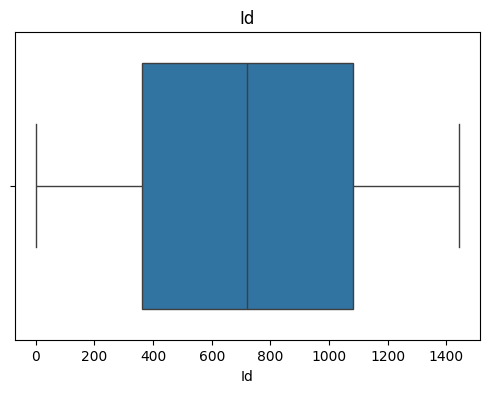

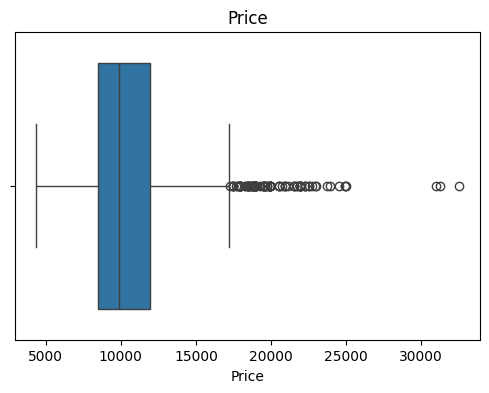

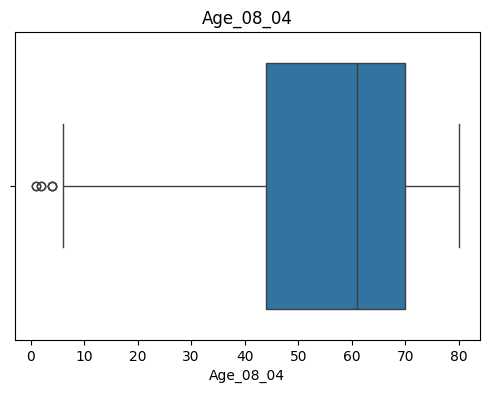

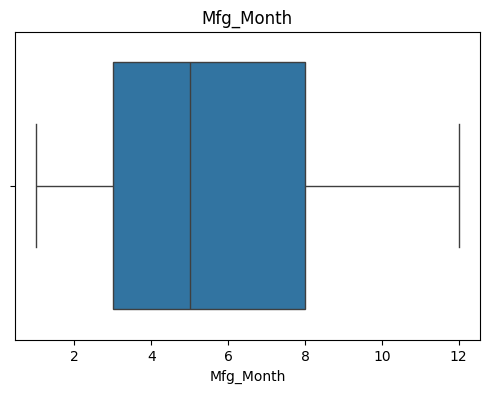

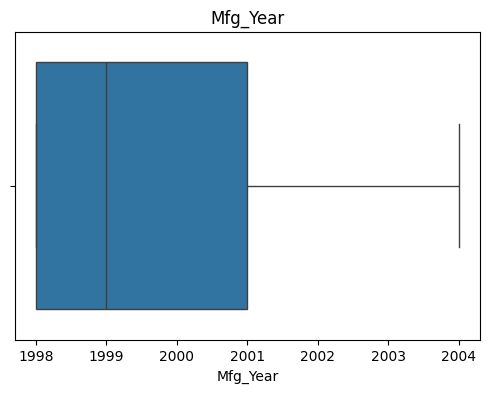

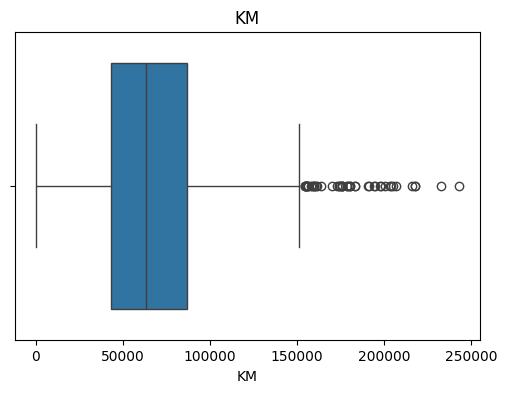

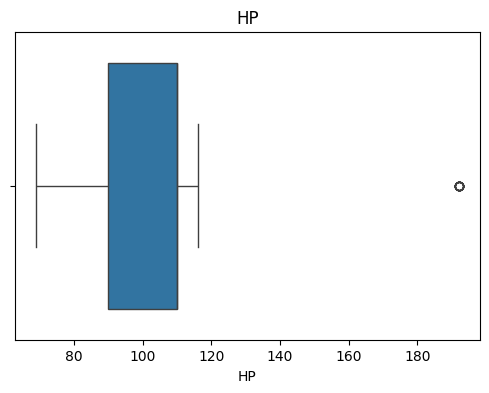

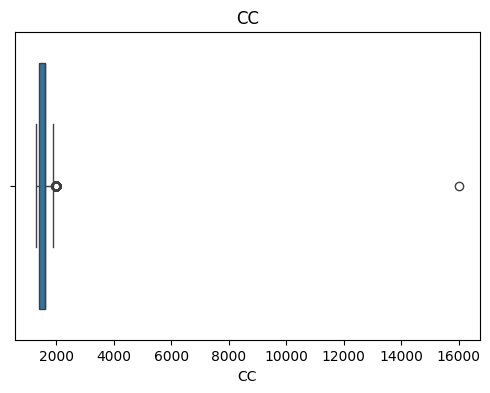

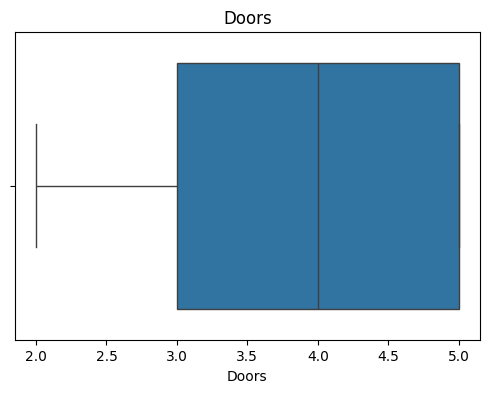

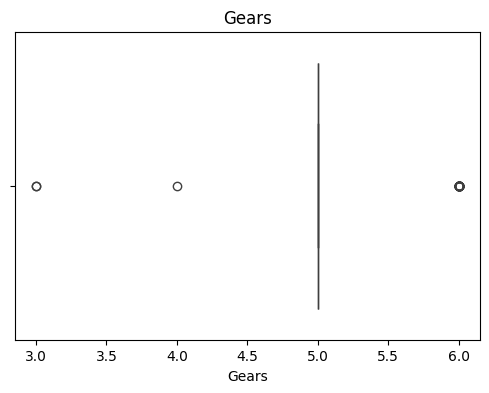

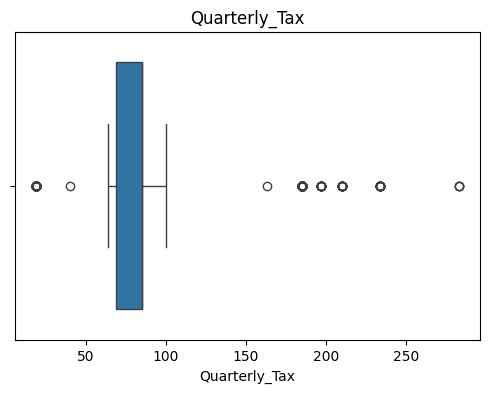

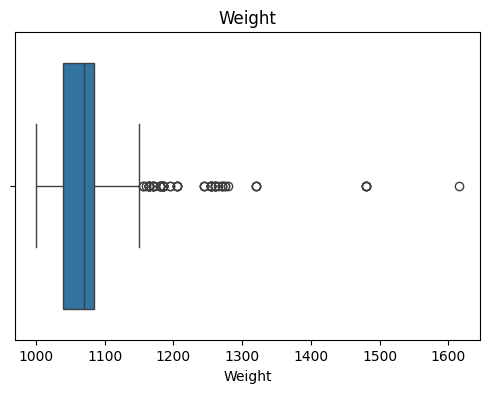

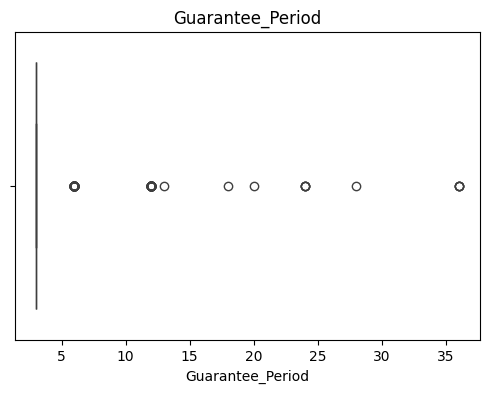

In [9]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=[np.number]).columns
continuous_cols = [col for col in num_cols if df[col].nunique() > 2] 
for col in continuous_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

признак id не берем в рассмотрение, не несёт полезной информации

price: много очень дорогих автомобилей

age: выраженная асимметрия, выбросы слева, значит есть новые автомобили, так и оставлю

пробег KM: много старых???

НР мощность: либо ошибка, либо редкое значение(скорее второе)

CC объём двигателя: наверняка ошибка в 16000

Gears количество передач: редкие значения 3, 4, 6 соответствуют реальным автомобилям, так что норм

Weight: ничего не делаем, могут быть тяжёлые автомобили

Guarantee_Period срок гарантии: тоже просто редкие значения.

In [10]:
# удаляю явную ошибку
error_mask = (df['CC'] > 6000)
df = df[~error_mask]
#удаляю id
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
# One-Hot Encoding
cat_cols = df.select_dtypes(include=['str']).columns
print("Категориальные признаки:", list(cat_cols))

Категориальные признаки: ['Model', 'Fuel_Type', 'Color']


In [11]:
#df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
#drop_first=True помогает избежать мультиколлинеарности (ловушки дамми-переменных)
#print(df.iloc[:, :12].head())

# плохая идея слишком много уникальных значений
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} уникальных значений")

Model: 318 уникальных значений
Fuel_Type: 3 уникальных значений
Color: 10 уникальных значений


In [12]:
print(df.columns.tolist())

['Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar']


In [13]:
cols_to_encode = ['Fuel_Type', 'Color']

# Удаляем признак модель
df = df.drop(columns=['Model'])

# Применяем one-hot encoding
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
df.shape

(1435, 46)

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Price              1435 non-null   int64
 1   Age_08_04          1435 non-null   int64
 2   Mfg_Month          1435 non-null   int64
 3   Mfg_Year           1435 non-null   int64
 4   KM                 1435 non-null   int64
 5   HP                 1435 non-null   int64
 6   Met_Color          1435 non-null   int64
 7   Automatic          1435 non-null   int64
 8   CC                 1435 non-null   int64
 9   Doors              1435 non-null   int64
 10  Cylinders          1435 non-null   int64
 11  Gears              1435 non-null   int64
 12  Quarterly_Tax      1435 non-null   int64
 13  Weight             1435 non-null   int64
 14  Mfr_Guarantee      1435 non-null   int64
 15  BOVAG_Guarantee    1435 non-null   int64
 16  Guarantee_Period   1435 non-null   int64
 17  ABS                1435 non-nu

In [15]:
corr = df.corr()
# Берём верхний треугольник без диагонали
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Преобразуем в список пар
high_corr = upper.stack().reset_index()
high_corr.columns = ['feature_1', 'feature_2', 'correlation']
high_corr = high_corr[abs(high_corr['correlation']) > 0.7].sort_values('correlation', ascending=False)

print(f"Найдено {len(high_corr)} пар с |corr| > 0.7")
if not high_corr.empty:
    print(high_corr.head(10))
else:
    print("Сильно коррелированных пар нет.")

Найдено 12 пар с |corr| > 0.7
          feature_1         feature_2  correlation
1274          Radio    Radio_cassette     0.991620
3             Price          Mfg_Year     0.885042
1129   Central_Lock   Powered_Windows     0.875488
587   Quarterly_Tax  Fuel_Type_Diesel     0.792863
403              CC  Fuel_Type_Diesel     0.761750
160        Mfg_Year     Boardcomputer     0.721965
68        Age_08_04     Boardcomputer    -0.720999
404              CC  Fuel_Type_Petrol    -0.734422
588   Quarterly_Tax  Fuel_Type_Petrol    -0.835600
1             Price         Age_08_04    -0.876377


пары, где участвует price не создают мультиколлинеарности: 
Price & Mfg_Year (0.885)
Price & Age_08_04 (-0.876)

radio_cassette удалю

ещё удалю Central_Lock

In [16]:
df = df.drop(columns=['Radio_cassette', 'Central_Lock'])

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

target = 'Price'
X = df.drop(columns=[target])   # все признаки
y = df[target]

# Преобразуем все bool-колонки в int
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# VIF для каждого признака
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Сортируем по убыванию VIF
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

C:\MyLEARNING\ML-course-HW\ml-hw\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\MyLEARNING\ML-course-HW\ml-hw\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


              feature        VIF
0           Age_08_04        inf
1           Mfg_Month        inf
2            Mfg_Year        inf
37         Color_Grey  81.701702
35         Color_Blue  77.722690
38          Color_Red  76.996255
36        Color_Green  64.111541
34        Color_Black  56.927124
39       Color_Silver  38.933054
32   Fuel_Type_Diesel  23.312840
33   Fuel_Type_Petrol  13.542847
41        Color_White  11.410654
7                  CC   9.508024
4                  HP   7.040960
11      Quarterly_Tax   5.263450
12             Weight   4.288388
18           Airbag_2   3.116079
28   Backseat_Divider   2.709609
21      Boardcomputer   2.673713
40       Color_Violet   2.398942
16                ABS   2.291256
3                  KM   2.132700
26          Mistlamps   2.081122
42       Color_Yellow   2.026096
19              Airco   1.863797
23    Powered_Windows   1.800174
20    Automatic_airco   1.757767
17           Airbag_1   1.630055
24     Power_Steering   1.591582
15   Guara

In [18]:
print(X.dtypes.value_counts())
print(X.dtypes)

int64    43
Name: count, dtype: int64
Age_08_04            int64
Mfg_Month            int64
Mfg_Year             int64
KM                   int64
HP                   int64
Met_Color            int64
Automatic            int64
CC                   int64
Doors                int64
Cylinders            int64
Gears                int64
Quarterly_Tax        int64
Weight               int64
Mfr_Guarantee        int64
BOVAG_Guarantee      int64
Guarantee_Period     int64
ABS                  int64
Airbag_1             int64
Airbag_2             int64
Airco                int64
Automatic_airco      int64
Boardcomputer        int64
CD_Player            int64
Powered_Windows      int64
Power_Steering       int64
Radio                int64
Mistlamps            int64
Sport_Model          int64
Backseat_Divider     int64
Metallic_Rim         int64
Parking_Assistant    int64
Tow_Bar              int64
Fuel_Type_Diesel     int64
Fuel_Type_Petrol     int64
Color_Black          int64
Color_Blue       

In [19]:
# удаляю линейно зависимые признаки
df = df.drop(columns=['Mfg_Year', 'Mfg_Month'], errors='ignore')

# Если Cylinders константен, удаляем
if df['Cylinders'].nunique() == 1:
    df = df.drop(columns=['Cylinders'])
# Дамми-переменные цвета (Color_*) имеют высокий VIF
# (от 11 до 81), что тоже указывает на мультиколлинеарность, хотя я использовала drop first
# всё-таки удалю цвета, думаю это не так важно для цены
color_cols = [col for col in df.columns if col.startswith('Color_')]
df = df.drop(columns=color_cols)

# пересчитываю
X = df.drop(columns=[target])   # все признаки
y = df[target]

bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

              feature         VIF
9              Weight  828.723357
7               Gears  614.358635
5                  CC  602.000220
2                  HP  265.605786
30   Fuel_Type_Petrol  106.528774
21     Power_Steering   69.694756
14           Airbag_1   54.419698
0           Age_08_04   44.015590
8       Quarterly_Tax   28.590493
6               Doors   25.130206
29   Fuel_Type_Diesel   23.603878
11    BOVAG_Guarantee   13.139763
13                ABS   12.037883
25   Backseat_Divider   11.680270
15           Airbag_2   11.062795
1                  KM    9.086201
20    Powered_Windows    4.066995
12   Guarantee_Period    3.982228
16              Airco    3.741893
18      Boardcomputer    3.631977
3           Met_Color    3.507570
23          Mistlamps    2.708593
10      Mfr_Guarantee    2.033752
24        Sport_Model    2.017540
19          CD_Player    1.970008
17    Automatic_airco    1.827698
26       Metallic_Rim    1.685634
28            Tow_Bar    1.599443
22            

у этих признаков допустим высокий vif наверное. кароч оставим как есть, пойдем дальше, там посмотрим

In [20]:
#Разделение на train/test и масштабирование
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

разделение нужно для честной оценки качества модели. если обучить на всех данных, а потом на них же проверить, будет слишком хорошая оценка. 80 на 20 - стандартное разделение

In [26]:
#обучение линейной регрессии
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Метрики
r2_lr = r2_score(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression")
print(f"R²: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.2f}")

Linear Regression (без регуляризации)
R²: 0.8760
RMSE: 1193.78


In [27]:
from sklearn.linear_model import RidgeCV

# Подбор alpha по кросс-валидации
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5, scoring='r2')
ridge.fit(X_train_scaled, y_train)

# Оптимальная alpha
print(f"Оптимальная alpha для Ridge: {ridge.alpha_:.4f}")

y_pred_ridge = ridge.predict(X_test_scaled)

# Метрики
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge Regression")
print(f"R²: {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")

Оптимальная alpha для Ridge: 1.1514
Ridge Regression
R²: 0.8759
RMSE: 1194.30


In [28]:
from sklearn.linear_model import LassoCV

# Подбор alpha по кросс-валидации
lasso = LassoCV(alphas=np.logspace(-3, 2, 50), cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Оптимальная alpha
print(f"Оптимальная alpha для Lasso: {lasso.alpha_:.4f}")

y_pred_lasso = lasso.predict(X_test_scaled)

# Метрики
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression")
print(f"R²: {r2_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.2f}")

# Количество ненулевых коэффициентов
coef_lasso = pd.Series(lasso.coef_, index=X.columns)
n_nonzero = (coef_lasso != 0).sum()
print(f"Количество признаков, оставленных Lasso: {n_nonzero}")

Оптимальная alpha для Lasso: 0.0010
Lasso Regression
R²: 0.8760
RMSE: 1193.78
Количество признаков, оставленных Lasso: 31


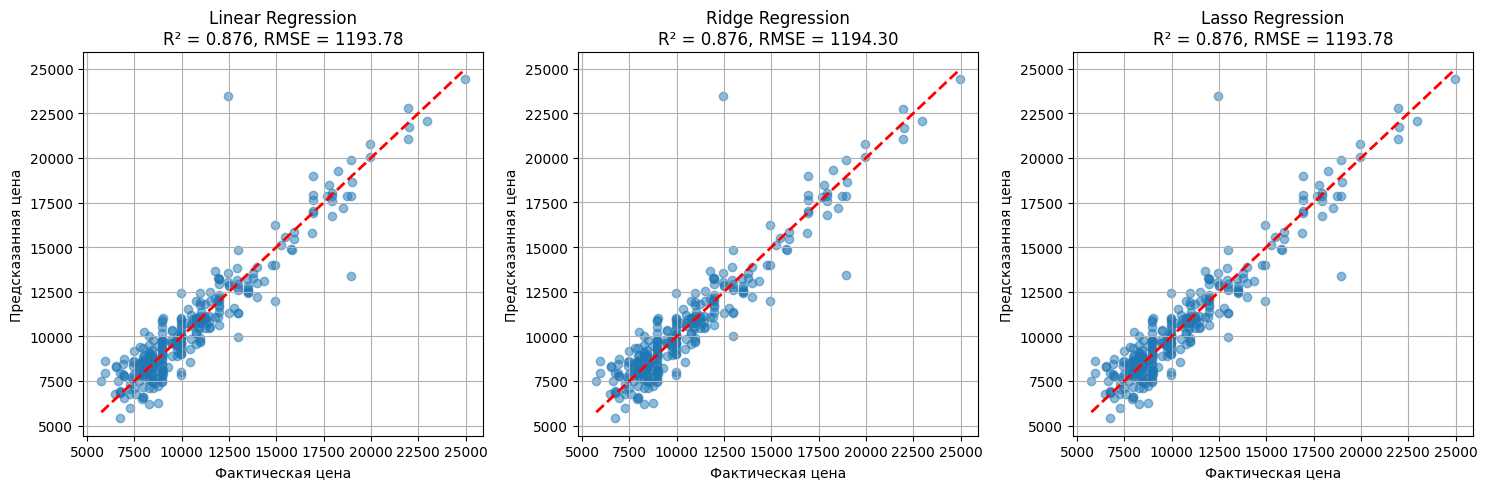

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактическая цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title(f'Linear Regression\nR² = {r2_lr:.3f}, RMSE = {rmse_lr:.2f}')
axes[0].grid()

# Ridge
axes[1].scatter(y_test, y_pred_ridge, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Фактическая цена')
axes[1].set_ylabel('Предсказанная цена')
axes[1].set_title(f'Ridge Regression\nR² = {r2_ridge:.3f}, RMSE = {rmse_ridge:.2f}')
axes[1].grid()

# Lasso
axes[2].scatter(y_test, y_pred_lasso, alpha=0.5)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Фактическая цена')
axes[2].set_ylabel('Предсказанная цена')
axes[2].set_title(f'Lasso Regression\nR² = {r2_lasso:.3f}, RMSE = {rmse_lasso:.2f}')
axes[2].grid()

plt.tight_layout()
plt.show()

видимо в моём случае регуляризация не особо влияет
Коэффициент детерминации R^2 – показывает, какую долю дисперсии целевой переменной (цены) объясняет модель

Среднеквадратичная ошибка (RMSE, Root Mean Squared Error) – измеряет среднюю ошибку предсказания в тех же единицах, что и целевая переменная 

результаты наверное норм, предсказывает 87.6% вариации цены

переобучения нет, если бы было, то на обучающих данных были бы хорошие результаты, а на тестовых плохие, у меня по графикам видно что почти норм.
кроме того, Ridge и Lasso, которые специально разработаны для борьбы с переобучением, дали практически такие же результаты, как и обычная регрессия. Если бы переобучение было значительным, регуляризация заметно изменила бы коэффициенты и ухудшила качество на обучении, но улучшила бы на тесте – этого не произошло.